# **Libraries**

In [ ]:
# Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from joblib import dump

# **Importing Dataset from Github**
***and labeling the collunms***

In [ ]:
import pandas as pd

# Load dataset from GitHub
url = 'https://raw.githubusercontent.com/Patcharadanai-Ket/HateSpeechDemo/refs/heads/main/Dataset.csv'
df = pd.read_csv(url)

# column names
print("Columns:", df.columns.tolist())

# Fill missing values in columns (blank)
df[['hate', 'offensive', 'neutral']] = df[['hate', 'offensive', 'neutral']].fillna(0)

# Create a new label column for the class with the highest value per text
df['label'] = df[['hate', 'offensive', 'neutral']].idxmax(axis=1)

# Preview
print(df.head())


Columns: ['text', 'hate', 'offensive', 'neutral']
                                                text  hate  offensive  \
0        I bought new tires for my car this morning.   0.0        0.0   
1  The local basketball team won their game last ...   0.0        0.0   
2  All the members of that political party are tr...   1.0        0.0   
3  This paperwork needs to be filed before the en...   0.0        0.0   
4  Look at that moron trying to park, what an abs...   0.0        1.0   

   neutral      label  
0      1.0    neutral  
1      1.0    neutral  
2      0.0       hate  
3      1.0    neutral  
4      0.0  offensive  


# **Data Cleaning**

In [ ]:
import re

def clean_text(text):
    text = str(text).lower() # lowercase
    text = re.sub(r'http\S+|www\S+', '', text) # URLs
    text = re.sub(r'[^a-z\s]', '', text) # non-letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

# Apply cleaning function text column
df.iloc[:, 0] = df.iloc[:, 0].apply(clean_text)

# **Defining params, test/train split**

In [ ]:
# Define X and Y / test train split
X = df.iloc[:, 0]   # first column = text
y = df['label']     # new label column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Vectorization + Logistic Regression + Model Fitting/Training**

In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words='english')),
    ("clf", LogisticRegression(max_iter=200))
])
model.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', LogisticRegression(max_iter=200))])

# **Evaluation and Report**

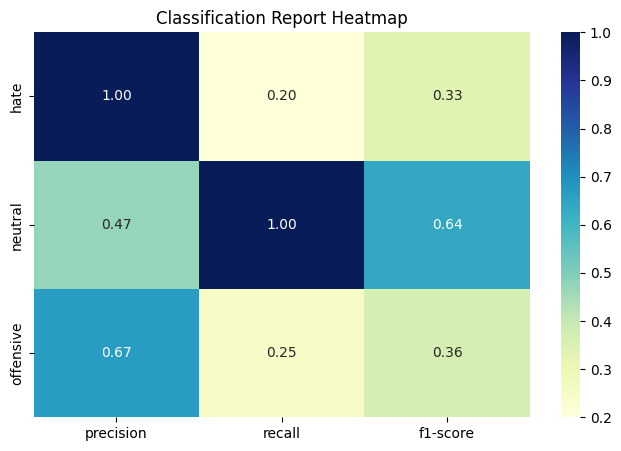

In [ ]:
# Evaluate
y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :3]

plt.figure(figsize=(8,5))
sns.heatmap(df_report.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Classification Report Heatmap')
plt.show()

# **Export model as file**

In [ ]:
from sklearn.pipeline import Pipeline

dump(model, "TrainedModel.joblib")

['TrainedModel.joblib']

# **Test with new string**

In [ ]:
# Get user input
user_text = input("Enter your text: ")

# Predict label directly using the pipeline
prediction = model.predict([user_text])

print("Predicted label:", prediction[0])


Enter your text: s
Predicted label: neutral
